In [1]:
%load_ext autoreload
%autoreload 2

# ignore warnings for readability
import warnings
warnings.filterwarnings('ignore')

import os
from os.path import join
from collections import defaultdict
import numpy as np
import pandas as pd
import tqdm
from sklearn.linear_model import LinearRegression

import logging
logging.getLogger('fontTools.subset').setLevel(logging.WARNING)

# matplotlib
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.style.use('euclid_stylesheet_v2.mplstyle')
mpl.rcParams['figure.dpi'] = 300

In [2]:
mdir = './saved_models'


def r2logm(r):
    # see preprocessing.ipynb for this measurement
    coef = 0.36752
    intercept = -5.30640
    return (np.log10(r)-intercept)/coef

In [3]:
datanames = ['wC50', 'wC100', 'dC50', 'dC100']
runnames = ['base', 'gals_nle', 'summ_nle', 'gnn_npe']
modelnames = ['msig', 'pamico', 'mamp', 'gals_nle', 'summ_nle', 'gnn_npe']
Nfolds = 10
folds = np.arange(Nfolds)

datatitles = dict(
    wC50='Wide $50\%$',
    wC100='Wide $100\%$',
    dC50='Deep $50\%$',
    dC100='Deep $100\%$'
)
modeltitles = dict(
    msig='$M$--$\sigma$',
    pamico=r'$M$--$\lambda_{\rm spec}$',
    mamp='MAMPOSSt',
    gals_nle='Galaxy-Net',
    summ_nle='Summary-Net',
    gnn_npe='Graph-Net',
    true='True',
    prior='Prior',
    dummy='Dummy'
)

In [4]:
from scipy.stats import skewnorm
from scipy.optimize import minimize


def fit_skewed_normal(p16, p50, p84):
    target_percentiles = [0.16, 0.50, 0.84]
    observed_values = [p16, p50, p84]

    def objective(params):
        loc, scale, alpha = params
        if scale <= 0:
            return np.inf
        skewed_gaussian = skewnorm(alpha, loc=loc, scale=scale)
        calculated_values = skewed_gaussian.ppf(target_percentiles)
        return np.sum((calculated_values - observed_values) ** 2)

    initial_guess = [p50, (p84 - p16) / 2, 0.5]
    result = minimize(objective, initial_guess)
    loc, scale, alpha = result.x
    return skewnorm(alpha, loc=loc, scale=scale)

In [5]:
# load train/test
header = 'APR24'
datadir = './data/processed'

theta, fold, ids, richs, zclus, Ngal = {}, {}, {}, {}, {}, {}
for d in datanames:
    dirpath = join(datadir, f'{header}{d}')
    print('Loading:', dirpath)
    theta[d] = np.load(join(dirpath, 'theta_batch.npy'))
    fold[d] = np.load(join(dirpath, 'folds_batch.npy'))
    ids[d] = np.load(join(dirpath, 'ids_batch.npy'))
    metas = np.load(join(dirpath, 'metas_batch.npy'))
    zclus[d] = metas[:, 3]  # cluster photometric redshift
    richs[d] = metas[:, 1]  # sum of AMICO photometry
    Ngal[d] = np.load(join(dirpath, 'x_sum.npy'))[:, -1]

Ndata = {d: len(theta[d]) for d in datanames}
print(Ndata)

Loading: ./data/processed/APR24wC50
Loading: ./data/processed/APR24wC100
Loading: ./data/processed/APR24dC50
Loading: ./data/processed/APR24dC100
{'wC50': 840, 'wC100': 907, 'dC50': 1998, 'dC100': 2014}


In [6]:
Nsamp = 100
preds = defaultdict(dict)
for d in datanames:
    for r in runnames:
        # setup
        if r == 'base':
            preds[d]['msig'] = np.ones((Ndata[d], 2))*np.nan
            preds[d]['pamico'] = np.ones((Ndata[d], 2))*np.nan
        else:
            preds[d][r] = np.full((Ndata[d], Nsamp, 1), np.nan)

        # load
        for f in folds:
            if r == 'gnn_npe':
                dirname = f'oct02_{r}_{d}_f{f}'
            else:
                dirname = f'apr24_{r}_{d}_f{f}'
            if r == 'base':
                # Msig
                samplefile = join(mdir, dirname, 'msig.npz')
                if not os.path.exists(samplefile):
                    print(f'Skipping {dirname}')
                    continue
                s = np.load(samplefile)
                place_ids = np.searchsorted(ids[d], s['ids'])
                np.put(preds[d]['msig'][:, 0], place_ids, s['pred'])
                np.put(preds[d]['msig'][:, 1], place_ids, s['std'])

                # Pamico
                samplefile = join(mdir, dirname, 'Pamico.npz')
                if not os.path.exists(samplefile):
                    print(f'Skipping {dirname}')
                    continue
                s = np.load(samplefile)
                place_ids = np.searchsorted(ids[d], s['ids'])
                np.put(preds[d]['pamico'][:, 0], place_ids, s['pred'])
                np.put(preds[d]['pamico'][:, 1], place_ids, s['std'])

            else:
                # ML models
                samplefile = join(mdir, dirname, 'posterior_samples.npy')
                if not os.path.exists(samplefile):
                    print(f'Skipping {dirname}')
                    continue
                s = np.load(samplefile)
                s = np.swapaxes(s, 0, 1)
                s = s[:, :Nsamp]  # subsample if necessary
                preds[d][r][fold[d] == f] = s

In [7]:
# load mamposst

mamnames = {
    'wC50': 'wide50', 'wC100': 'wide100', 'dC50': 'deep50', 'dC100': 'deep100'
}
modeldir = './saved_models/mamposst_newprior_dec1824/'

for k, v in mamnames.items():
    isamp = pd.read_csv(join(modeldir, f'result_MockFS_NewAMICO_{v}.dat'),
                        delimiter=' ', skipinitialspace=True)
    isamp['id'] = isamp['#ClusterID'].astype(int)
    # convert r200 to logm
    for c in isamp.columns:
        if 'r200' not in c:
            continue
        isamp['logm'+c[4:]] = r2logm(isamp[c])

    # put in preds
    preds[k]['mamp'] = np.ones((Ndata[k], 5))*np.nan
    place_ids = np.searchsorted(ids[k], isamp['id'].values)
    mask = place_ids < Ndata[k]
    _s = isamp[['logmlow(68)', 'logmup(68)', 'logmlow(95)',
                'logmup(95)', 'logmMAM']].values
    preds[k]['mamp'][place_ids[mask]] = _s[mask]

In [8]:
# calculate percentiles from predictions
q = 100*np.array([0.16, 0.84, 0.5, 0.025, 0.975])
percs = defaultdict(dict)
for d in datanames:
    for m in modelnames:
        if m == 'msig' or m == 'pamico':
            t_ = preds[d][m]
            percs[d][m] = np.stack(
                [t_[:, 0]-t_[:, 1], t_[:, 0]+t_[:, 1], t_[:, 0],
                    t_[:, 0]-2*t_[:, 1], t_[:, 0]+2*t_[:, 1]],
                axis=1).T
        elif m == 'mamp':
            if m not in preds[d]:
                continue
            t_ = preds[d][m]
            percs[d][m] = np.stack(
                [t_[:, 0], t_[:, 1], t_[:, 4], t_[:, 2], t_[:, 3]],
                axis=1).T
        else:
            t_ = preds[d][m]
            percs[d][m] = np.percentile(t_, q, axis=1)[..., 0]
# percs is of shape (5, Ndata)
# dim 0 is of order [16, 84, 50, 2.5, 97.5]

In [10]:
# Compute quality control
def quality_control(percs):
    # checks if we have a reasonable median prediction
    # checks if we're not missing a prediction (not nan)
    med = percs[2]
    mask = (med > 12) & (med < 16)

    err = (percs[1] - percs[0])/2
    mask &= err < 1
    return mask


qc = defaultdict(dict)
for d in datanames:
    for m in modelnames:
        qc[d][m] = quality_control(percs[d][m])

In [11]:
# Remove Ngal < 3
for d in datanames:
    mask = Ngal[d] >= 3

    theta[d] = theta[d][mask]
    fold[d] = fold[d][mask]
    ids[d] = ids[d][mask]
    richs[d] = richs[d][mask]
    zclus[d] = zclus[d][mask]
    Ngal[d] = Ngal[d][mask]
    Ndata[d] = len(theta[d])

    for m in modelnames:
        if m not in percs[d]:
            continue
        preds[d][m] = preds[d][m][mask]
        percs[d][m] = percs[d][m][:, mask]
        qc[d][m] = qc[d][m][mask]

IndexError: boolean index did not match indexed array along dimension 0; dimension is 840 but corresponding boolean dimension is 764

## MCMC

Forward parametrization of the mass-richness relation (see `8_newappendix.tex`).
We model $p(\log_{10}\lambda\,|\,m, z, \theta)$, Gaussian in log-richness with
mean linear in mass.

**v5 imposes a $z$-dependent population prior $\phi(m|z)$** in place of the flat
training prior $p(m)=\mathcal N(m_0,\sigma_0^2)$ used to generate the mass
posteriors. The forward operand keeps the ratio term
$\ln[\phi(m|z)/p(m)]$ (Eq. for $\Gamma$ in `8_newappendix.tex`), which is
$\theta$-independent and so is **precomputed once** as a per-sample reweighting
`logw` and added inside the log-sum-exp. With $\phi(m|z)=\mathcal N(\mu_\phi(z),
\sigma_\phi^2)$ and $\mu_\phi(z)=a+b\log_{10}\frac{1+z}{1+z_0}$ fit from the true
masses, this importance-reweights each cluster's mass samples toward $\phi$ at
its redshift (e.g. pulling high-$z$ masses down). Watch the ESS diagnostic: a
$\phi$ far from $p$ shrinks the effective sample size.

Sampled parameters: $\theta = \{\pi_0, F_m, G_z, \sigma_\lambda\}$.

In [12]:
# LinearRegression to estimate the FORWARD relation: log10(lambda) | m, z
# (new appendix parametrization, see 8_newappendix.tex)
d = 'dC100'
rs = richs[d]
zs = zclus[d]
mtrue = theta[d][:, 0]

# find pivots: mass pivot m0 and redshift pivot z0
m0_piv, z0 = 14.0, 1.0

# regress log10(lambda) on (m - m0) and log10((1+z)/(1+z0))
dm = mtrue - m0_piv
dz = np.log10((1+zs)/(1+z0))
X = np.stack([dm, dz], axis=1)
ylam = np.log10(rs)
reg = LinearRegression().fit(X, ylam)
y_pred = reg.predict(X)
residual_std = np.std(ylam - y_pred)
print(f'pi0 (intercept): {reg.intercept_:.3f}')
print(f'F_m  (mass slope): {reg.coef_[0]:.3f}')
print(f'G_z  (redshift slope): {reg.coef_[1]:.3f}')
print(f'sigma_lambda (residual std): {residual_std:.3f}')

pi0 (intercept): 1.409
F_m  (mass slope): 0.334
G_z  (redshift slope): 2.075
sigma_lambda (residual std): 0.134


In [ ]:
import jax
import jax.numpy as jnp
from jax.scipy.special import logsumexp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
import corner

# Forward (new appendix) parametrization WITH an imposed z-dependent prior.
# Mean of the relation (Gaussian in log10 lambda):
#   <log10 lambda | m, z> = pi0 + Fm*(m - m0) + Gz*log10((1+z)/(1+z0))
# The general operand keeps the mass-prior ratio
#   Gamma_i(m) = -(loglam - mean)^2/(2 sigl^2) + ln[phi(m|z)/p(m)].
# The ratio is theta-independent, so we precompute it once as `logw`
# (shape (Nclu, Nsamp)) and add it inside the LSE -- an importance reweighting
# of each posterior's mass samples from the training prior p(m) to phi(m|z).
# theta = {pi0, Fm, Gz, sigl}; m0, z0 are fixed mass/redshift pivots.


def lamb_mean(m, zs, m0, z0, pi0, Fm, Gz):
    # mean of log10(lambda) given mass m and redshift z
    return pi0 + Fm*(m - m0) + Gz*(jnp.log10((1+zs)/(1+z0)))


def operand(samps, loglambs, zs, m0, z0, sigl, pi0, Fm, Gz, logw):
    # Gamma_i(m, theta); samps is (Nclu, Nsamp), logw is (Nclu, Nsamp) the
    # precomputed ln[phi(m|z)/p(m)] reweighting (zeros recovers phi = p).
    lam_est = lamb_mean(samps, zs[:, None], m0, z0, pi0, Fm, Gz)
    resid = -(loglambs[:, None] - lam_est)**2/(2*(sigl**2))
    return resid + logw


def log_likelihood(samps, loglambs, zs, m0, z0, sigl, pi0, Fm, Gz, logw):
    Nclu, Nsamp = samps.shape
    to_sum = operand(samps, loglambs, zs, m0, z0, sigl, pi0, Fm, Gz, logw)
    summed = logsumexp(to_sum, axis=1)         # LSE over mass samples, (Nclu,)
    out = -Nclu*jnp.log(sigl) - Nclu*jnp.log(Nsamp) + jnp.sum(summed)
    return out


def model(samps, loglambs, zs, m0, z0, logw):
    pi0 = numpyro.sample("pi0", dist.Uniform(-2, 5))
    Fm = numpyro.sample("Fm", dist.Uniform(-10, 10))
    Gz = numpyro.sample("Gz", dist.Uniform(-10, 10))
    sigl = numpyro.sample("sigl", dist.LogUniform(1e-2, 2.0))
    numpyro.factor(
        "log_likelihood",
        log_likelihood(samps, loglambs, zs, m0, z0, sigl, pi0, Fm, Gz, logw))


def run_mcmc(samps, loglambs, zs, m0, z0, logw,
             warmup=500, samples=1000, chains=4):
    mcmc = MCMC(NUTS(model), num_warmup=warmup,
                num_samples=samples, num_chains=chains,
                chain_method='vectorized')
    mcmc.run(jax.random.PRNGKey(0), samps=samps, loglambs=loglambs,
             zs=zs, m0=m0, z0=z0, logw=logw)
    return mcmc.get_samples()

In [14]:
# ============================================================
# Likelihood playground -- set the knobs here
# ============================================================
d = 'dC100'        # dataset: wC50, wC100, dC50, dC100
m = 'gnn_npe'        # mass model: msig, pamico, mamp, gals_nle, summ_nle,
#             gnn_npe, true, dummy
m0_piv, z0 = 13.78, 0.82     # mass and redshift pivots
m0, sig0 = 13.78, 0.348      # assumed mass prior p(m) ~ N(m0, sig0^2)
# ============================================================

rs = richs[d]
zs = zclus[d]
ytrue = theta[d][:, 0]

# build mass posterior samples `samps` of shape (Nclu, Nsamp)
if m in ['msig', 'pamico']:
    mu, sig = preds[d][m].T
    samps = mu[:, None] + sig[:, None]*np.random.randn(len(mu), Nsamp)
elif m == 'mamp':
    ps = preds[d][m]
    p16, p84, p50 = ps[:, 0], ps[:, 1], ps[:, 4]
    samps = np.array([
        fit_skewed_normal(p16[i], p50[i], p84[i]).rvs(Nsamp)
        if not np.isnan(p16[i]) else np.full(Nsamp, np.nan)
        for i in tqdm.tqdm(range(len(p16)))
    ])
elif m == 'dummy':
    # synthetic posteriors for testing the likelihood: noisy + prior-shrunk
    mu_p, sig_p = 13.78, 0.35   # mock inference prior p(m)
    sigma_n = 0.3               # injected noise (dex)
    post_var = 1.0/(1.0/sigma_n**2 + 1.0/sig_p**2)
    x = ytrue + sigma_n*np.random.randn(len(ytrue))
    post_mean = post_var*(x/sigma_n**2 + mu_p/sig_p**2)
    samps = (post_mean[:, None]
             + np.sqrt(post_var)*np.random.randn(len(ytrue), Nsamp))
    qc[d]['dummy'] = qc[d]['gnn_npe']
elif m == 'prior':
    # samps = np.random.randn(len(ytrue), Nsamp) * sig0 + m0
    samps = np.random.randn(len(ytrue), Nsamp) * sig0 + \
        reg_mz.predict(zs.reshape(-1, 1))[:, None]
    qc[d]['prior'] = qc[d]['gnn_npe']
elif m == 'true':
    samps = ytrue[:, None]
    qc[d]['true'] = qc[d]['gnn_npe']
else:
    samps = preds[d][m][..., 0]

# quality control + observed log10 richness (the "data" in the likelihood)
mask = qc[d][m]
# mask &= (0.75 < zs) & (zs < 0.8)
rs, zs, samps, ytrue = rs[mask], zs[mask], samps[mask], ytrue[mask]
loglambs = np.log10(rs)

print('samps shape:', samps.shape)
print('true mass mean/std:', ytrue.mean(), ytrue.std())

samps shape: (2014, 100)
true mass mean/std: 13.776200370712232 0.3479471949306839


In [15]:
# # OPTIONAL: smooth + resample each cluster's mass posterior with a Gaussian KDE.
# # Operates on the existing `samps` from the cell above. Comment out the final
# # `samps = kde_resample(samps)` line (or skip this cell) to keep the raw samples.
# from scipy.stats import gaussian_kde


# def kde_resample(samps, n=None, bw=None, seed=0):
#     # fit a 1D Gaussian KDE per cluster and draw `n` new mass samples
#     rng = np.random.default_rng(seed)
#     n = samps.shape[1] if n is None else n
#     out = np.empty((samps.shape[0], n))
#     for i in range(samps.shape[0]):
#         si = samps[i][np.isfinite(samps[i])]
#         if si.size < 2 or np.ptp(si) == 0:
#             # too few / degenerate samples: pass through (or NaN if empty)
#             out[i] = np.full(n, np.nan if si.size == 0 else si[0])
#             continue
#         out[i] = gaussian_kde(si, bw_method=bw).resample(n, seed=rng).ravel()
#     return out


# samps = kde_resample(samps, 1000)
# print('KDE-resampled samps shape:', samps.shape)

In [16]:
# ============================================================
# Impose a z-dependent population prior phi(m|z) in place of the flat
# TRAINING prior p(m) = N(m0, sig0^2). Fit phi from the true masses:
#   phi(m|z) = N(mu_phi(z), sig_phi^2),  mu_phi(z) = a + b*log10((1+z)/(1+z0)).
# (Replace reg_phi/sig_phi with any desired prior; set logw=0 to recover phi=p.)
# ============================================================
dz_all = np.log10((1 + zs) / (1 + z0))
reg_phi = LinearRegression().fit(dz_all[:, None], ytrue)
mu_phi_all = reg_phi.predict(dz_all[:, None])          # (Nclu,)
sig_phi = np.std(ytrue - mu_phi_all)
print(f'phi(m|z): mu = {reg_phi.intercept_:.3f} + {reg_phi.coef_[0]:.3f}*dz,'
      f'  sig_phi = {sig_phi:.3f}')
print(f'training prior p(m): N({m0:.3f}, {sig0:.3f}^2)')


def prior_logratio(samps, mu_phi, sig_phi, m0, sig0):
    # ln phi(m|z) - ln p(m), dropping m-independent (theta-independent) consts
    lphi = -(samps - mu_phi[:, None])**2 / (2*sig_phi**2)
    lp = -(samps - m0)**2 / (2*sig0**2)
    return lphi - lp


# precompute the (Nclu, Nsamp) reweighting once -- it does not depend on theta
logw = prior_logratio(samps, mu_phi_all, sig_phi, m0, sig0)
print('logw shape:', logw.shape, '| mean abs:', np.abs(logw).mean())

phi(m|z): mu = 13.783 + -0.551*dz,  sig_phi = 0.345
training prior p(m): N(13.780, 0.348^2)
logw shape: (2014, 100) | mean abs: 0.09000851484304877


In [17]:
# Run MCMC (forward likelihood, imposed z-dependent prior) with posterior masses
samples = run_mcmc(samps, loglambs, zs, m0_piv, z0, logw,
                   samples=2000, chains=2)
print(samps.mean())

sample: 100%|██████████| 2500/2500 [01:00<00:00, 41.23it/s]


13.780167335692086


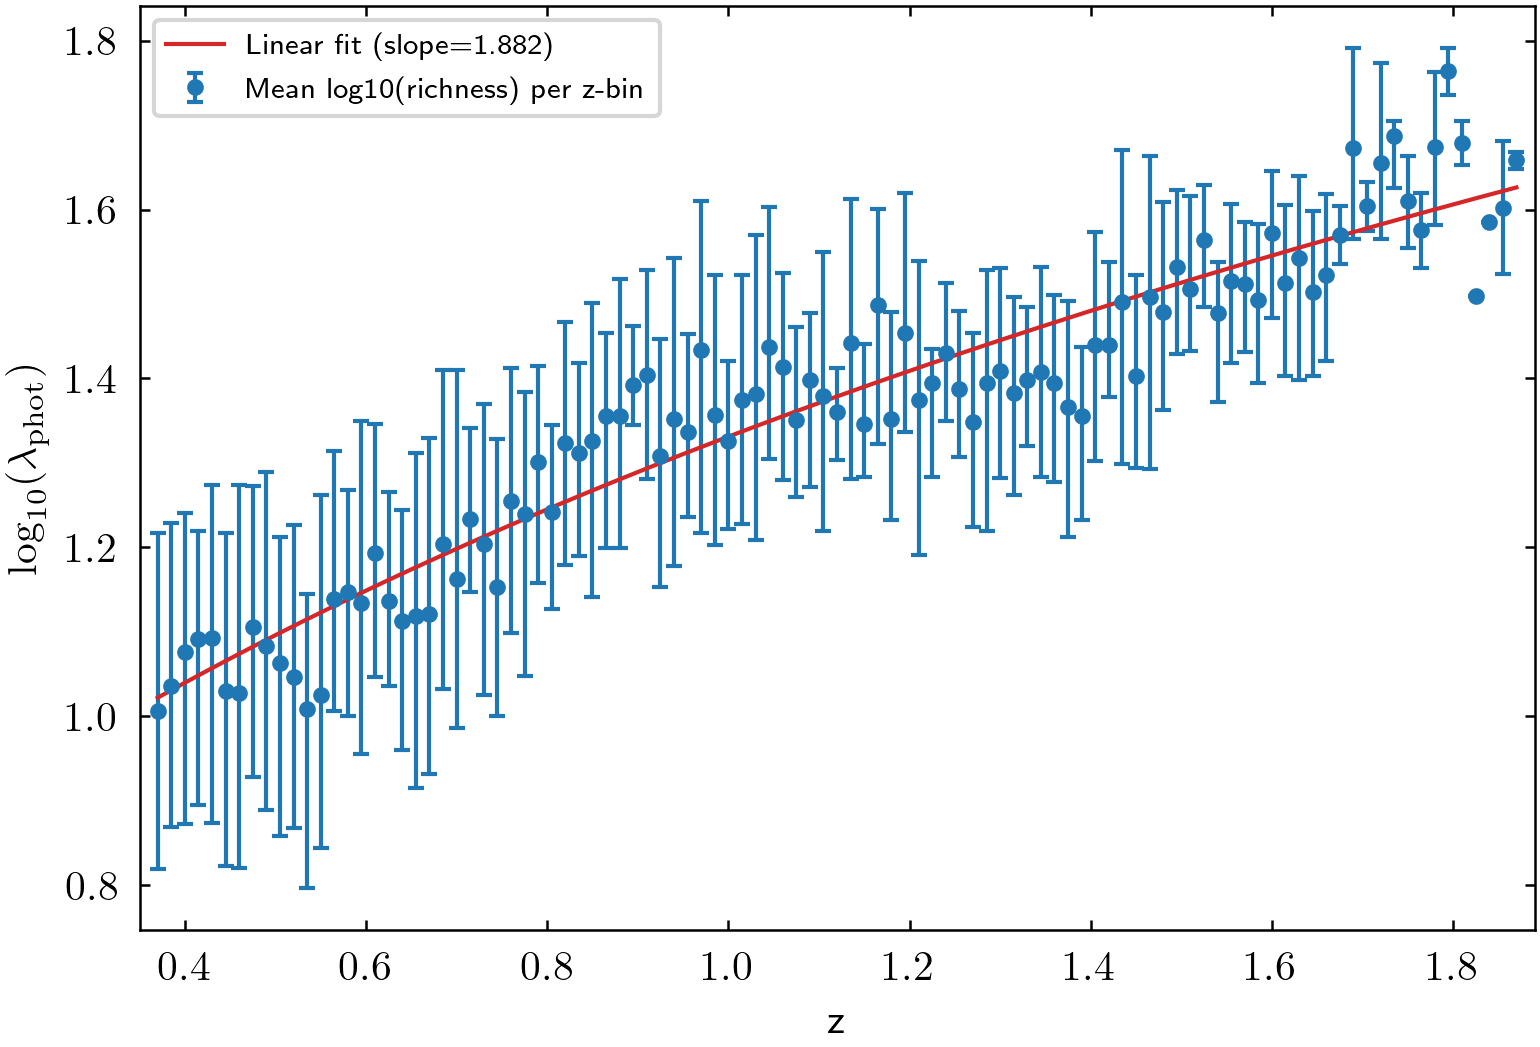

In [18]:
zvals = np.sort(np.unique(zs))
groups = [loglambs[zs == z] for z in zvals]

means = np.array([g.mean() for g in groups])
p16 = np.array([np.percentile(g, 16) for g in groups])
p84 = np.array([np.percentile(g, 84) for g in groups])

# Linear fit: mean log10(lambda) vs log10((1+z)/(1+z0))
dz_vals = np.log10((1 + zvals) / (1 + z0))
reg_mz = LinearRegression().fit(dz_vals[:, None], means)
dz_grid = np.linspace(dz_vals.min(), dz_vals.max(), 200)
fit_line = reg_mz.predict(dz_grid[:, None])
zvals_grid = (1 + z0) * 10**dz_grid - 1

plt.figure(figsize=(6, 4))
plt.errorbar(
    zvals, means,
    yerr=[means - p16, p84 - means],
    fmt='o', ms=3, capsize=2, elinewidth=1, label='Mean log10(richness) per z-bin'
)
plt.plot(zvals_grid, fit_line, 'C3-',
         label=f'Linear fit (slope={reg_mz.coef_[0]:.3f})')
plt.xlabel('z')
plt.ylabel(r'$\log_{10}(\lambda_{\rm phot})$')
plt.xlim(zvals.min() - 0.02, zvals.max() + 0.02)
plt.legend(fontsize=7)

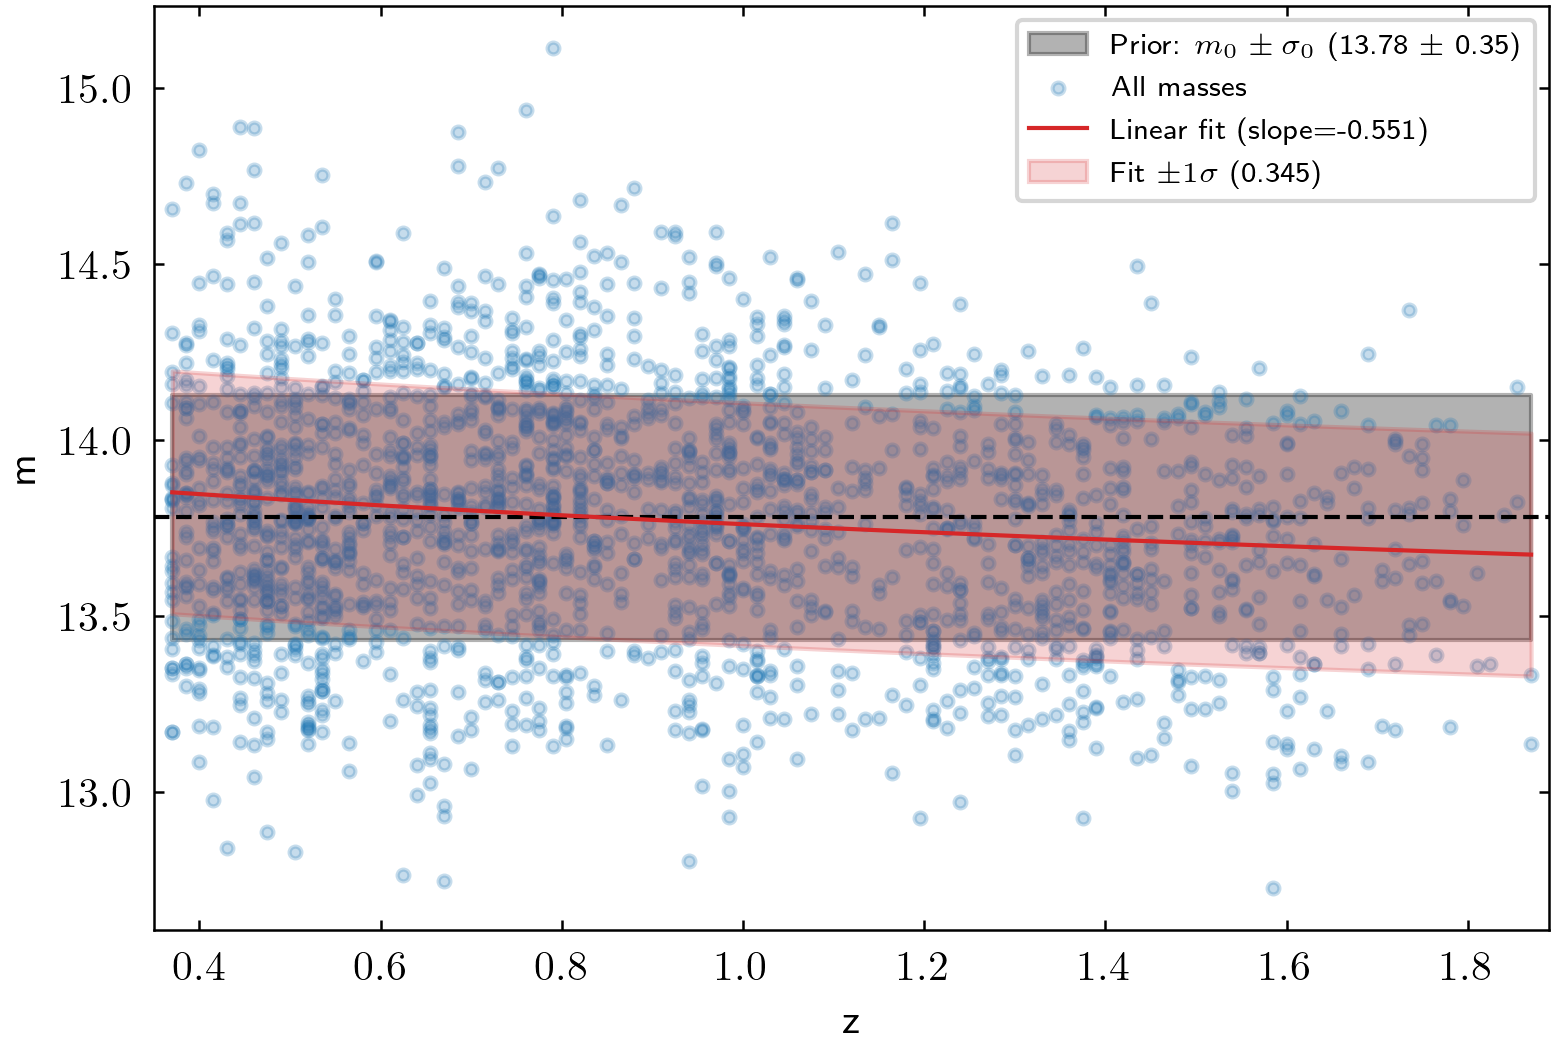

In [19]:
# Regress all values, not the binned means
dz_all = np.log10((1 + zs) / (1 + z0))
reg_mz = LinearRegression().fit(dz_all[:, None], ytrue)

dz_grid = np.linspace(dz_all.min(), dz_all.max(), 200)
fit_line = reg_mz.predict(dz_grid[:, None])
zvals_grid = (1 + z0) * 10**dz_grid - 1

# 1-sigma scatter around the fit, computed from all points
fit_resid = ytrue - reg_mz.predict(dz_all[:, None])
fit_std = np.std(fit_resid)

plt.figure(figsize=(6, 4))

plt.fill_between(
    zvals_grid,
    np.full_like(zvals_grid, m0 - sig0),
    np.full_like(zvals_grid, m0 + sig0),
    color='k',
    alpha=0.3,
    label=fr'Prior: $m_0 \pm \sigma_0$ ({m0:.2f} ± {sig0:.2f})'
)
plt.axhline(m0, color='k', ls='--', lw=1)

plt.scatter(zs, ytrue, s=8, alpha=0.25, label='All masses')

plt.plot(zvals_grid, fit_line, 'C3-',
         label=f'Linear fit (slope={reg_mz.coef_[0]:.3f})')
plt.fill_between(
    zvals_grid,
    fit_line - fit_std,
    fit_line + fit_std,
    color='C3',
    alpha=0.2,
    label=fr'Fit $\pm 1\sigma$ ({fit_std:.3f})'
)

plt.xlabel('z')
plt.ylabel('m')
plt.xlim(zvals.min() - 0.02, zvals.max() + 0.02)
plt.legend(fontsize=7)

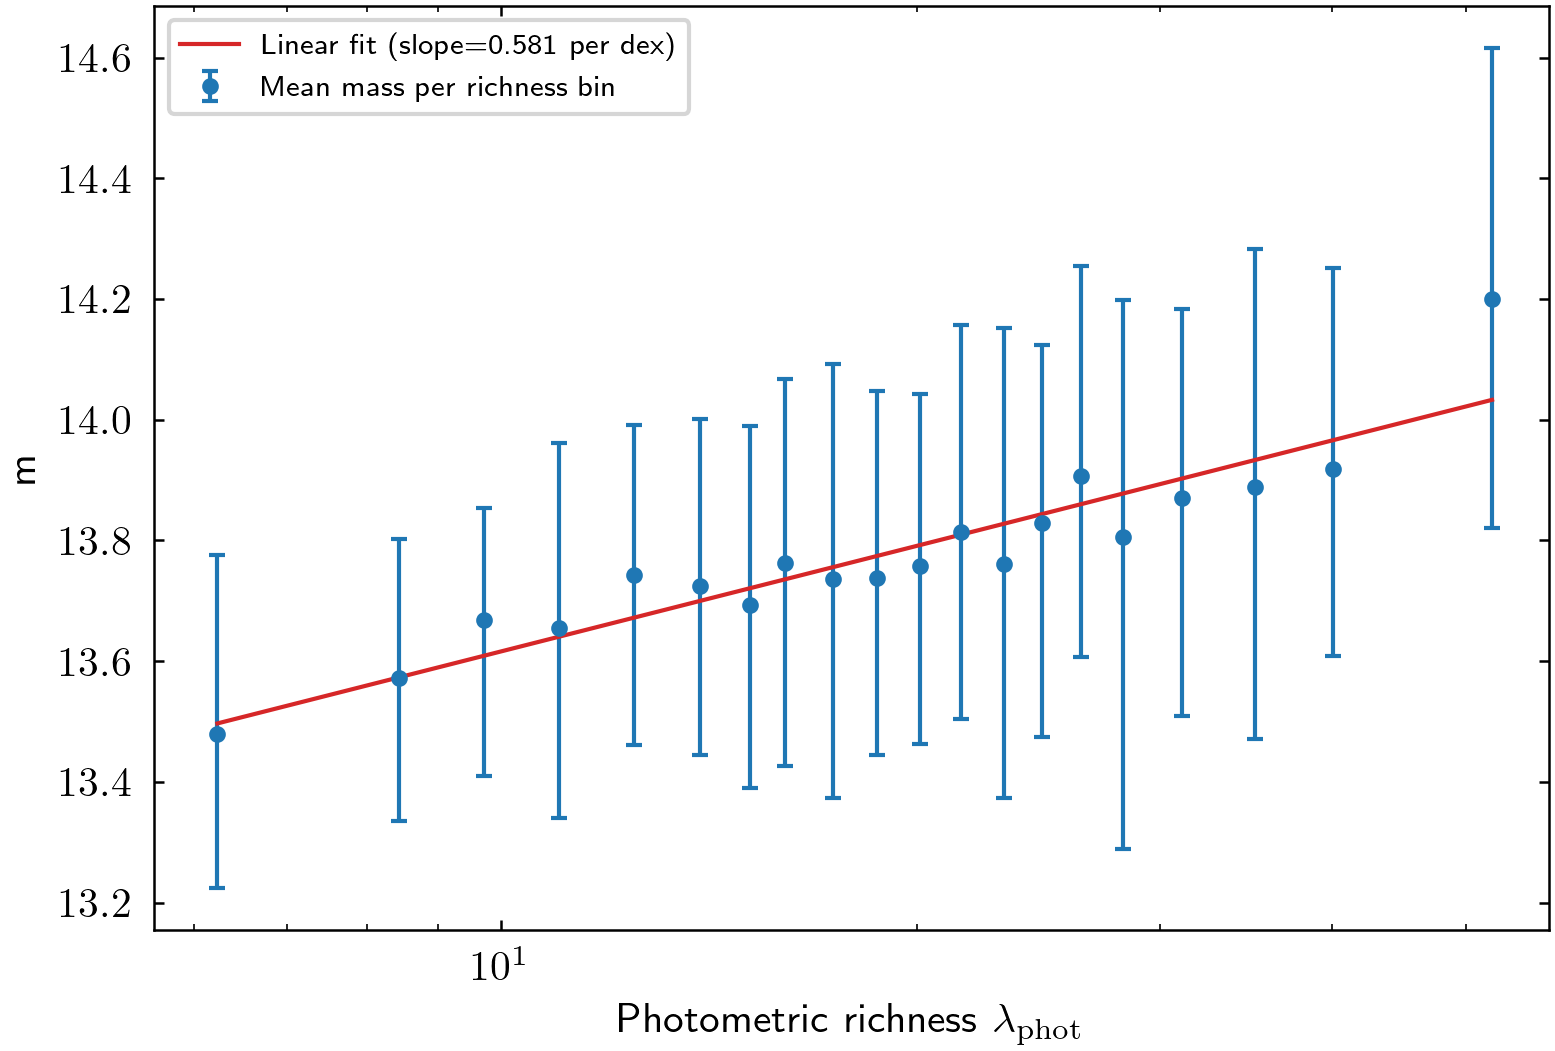

In [20]:
# Mean mass as a function of photometric richness
nbins = 20
edges = np.quantile(rs, np.linspace(0, 1, nbins + 1))
edges = np.unique(edges)  # guard against duplicated edges

bin_id = np.digitize(rs, edges[1:-1])
x_mid, means, p16, p84 = [], [], [], []

for i in range(len(edges) - 1):
    g = ytrue[bin_id == i]
    xg = rs[bin_id == i]
    if len(g) == 0:
        continue
    x_mid.append(np.median(xg))
    means.append(g.mean())
    p16.append(np.percentile(g, 16))
    p84.append(np.percentile(g, 84))

x_mid = np.array(x_mid)
means = np.array(means)
p16 = np.array(p16)
p84 = np.array(p84)

# Linear fit: mean mass vs log10(richness)
xfit = np.log10(x_mid)
reg_mr = LinearRegression().fit(xfit[:, None], means)

x_grid = np.logspace(np.log10(x_mid.min()), np.log10(x_mid.max()), 200)
y_grid = reg_mr.predict(np.log10(x_grid)[:, None])

plt.figure(figsize=(6, 4))
plt.errorbar(
    x_mid, means,
    yerr=[means - p16, p84 - means],
    fmt='o', ms=3, capsize=2, elinewidth=1, label='Mean mass per richness bin'
)
plt.plot(x_grid, y_grid, 'C3-',
         label=f'Linear fit (slope={reg_mr.coef_[0]:.3f} per dex)')
plt.xscale('log')
plt.xlabel(r'Photometric richness $\lambda_{\rm phot}$')
plt.ylabel('m')
plt.xlim(x_mid.min() * 0.9, x_mid.max() * 1.1)
plt.legend(fontsize=7)

In [21]:
# Run MCMC with true masses for reference.
# (Reweighting a delta-function posterior is a no-op, so logw = 0 here.)
truesamples = run_mcmc(ytrue[:, None], loglambs, zs, m0_piv, z0,
                       np.zeros_like(ytrue[:, None]),
                       samples=2000, chains=4)
print(ytrue.mean())

sample: 100%|██████████| 2500/2500 [00:06<00:00, 386.75it/s]


13.776200370712232


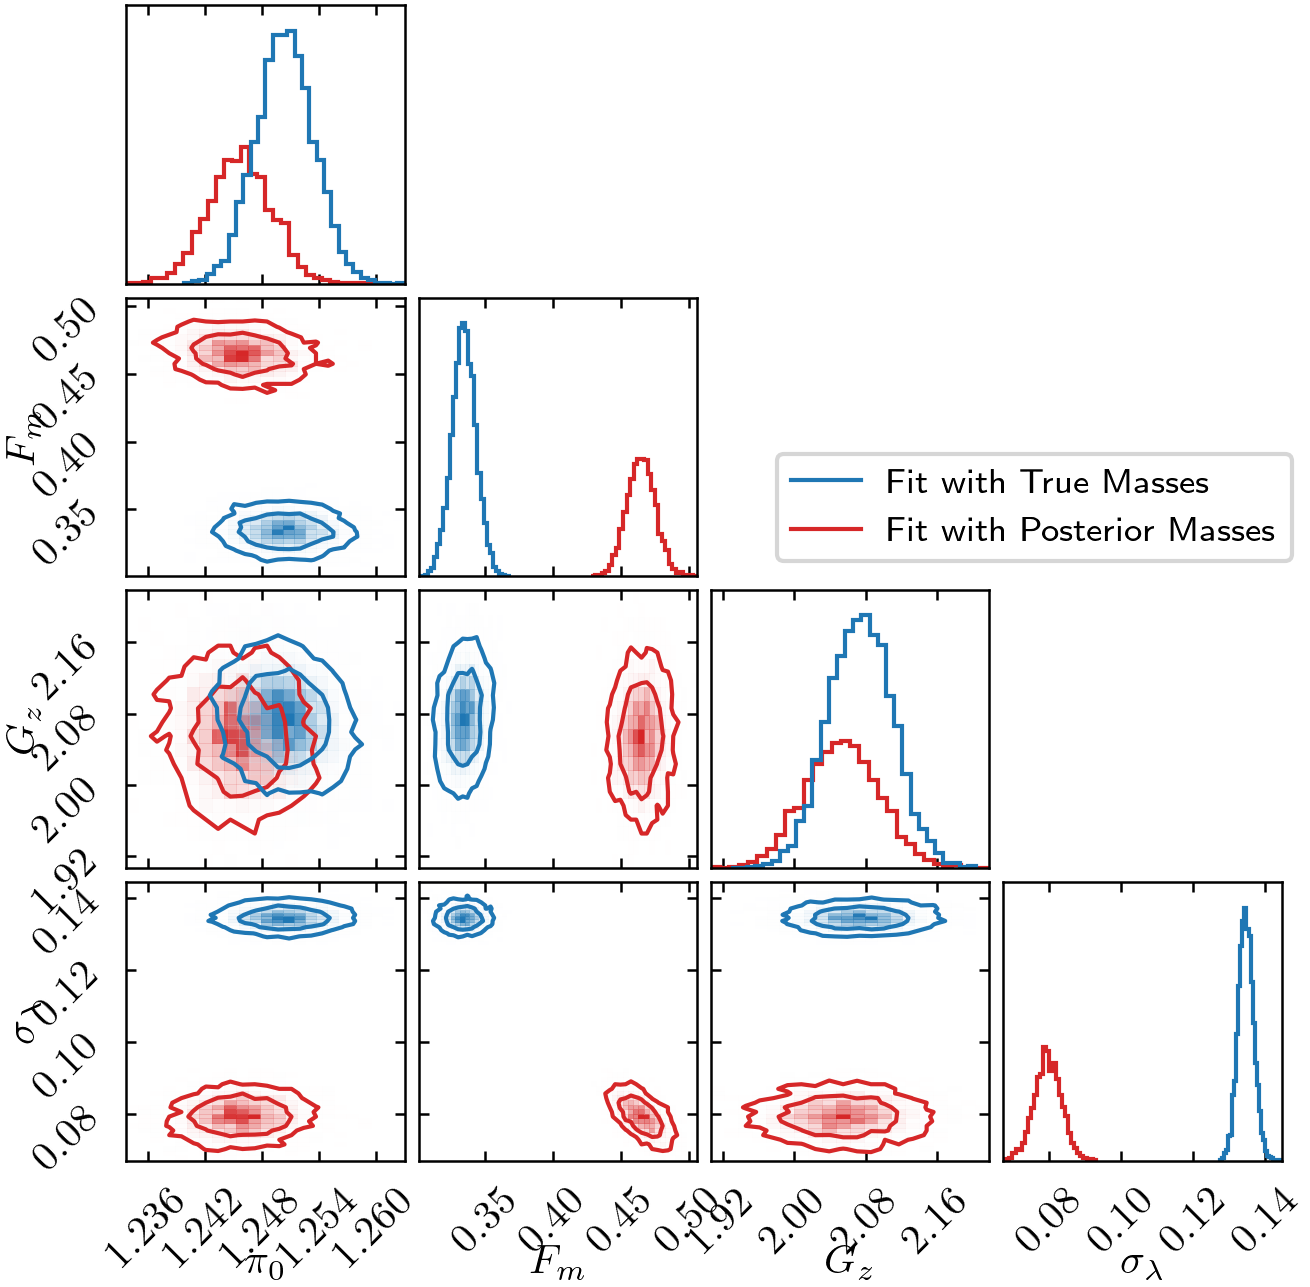

In [22]:
# plot the corner plot
fig = plt.figure(figsize=(4.5, 4.5))

# parameter ranges; set to a list of (lo, hi) per param to fix the axes
ranges = None

labels = [r"$\pi_0$", r"$F_m$", r"$G_z$", r"$\sigma_\lambda$"]

# Fit with Posterior Masses
data = np.vstack(
    [samples['pi0'], samples['Fm'], samples['Gz'], samples['sigl']]
).T
corner.corner(
    data,
    labels=labels,
    levels=[0.68, 0.95],
    range=ranges,
    fig=fig,
    color='C3',
    alpha=0.1, plot_contours=True,  # smooth=0.5, smooth1d=0.5,
    hist_bin_factor=1.5,
    plot_datapoints=False, no_fill_contours=True
)

# Fit with True Masses
data = np.vstack(
    [truesamples['pi0'], truesamples['Fm'], truesamples['Gz'],
     truesamples['sigl']]
).T
corner.corner(
    data,
    labels=labels,
    levels=[0.68, 0.95],
    range=ranges,
    fig=fig,
    color='C0',
    plot_contours=True,  # smooth=0.5, smooth1d=0.5,
    hist_bin_factor=1.5,
    plot_datapoints=False, no_fill_contours=True,
)

plt.plot([], [], color='C0', label='Fit with True Masses')
plt.plot([], [], color='C3', label='Fit with Posterior Masses')

# Add the legend
plt.legend(loc='upper right', bbox_to_anchor=(1.1, 2.6), fontsize='small')

# fig.savefig(f'figures/lambdam_corner_{d}.pdf', bbox_inches='tight')

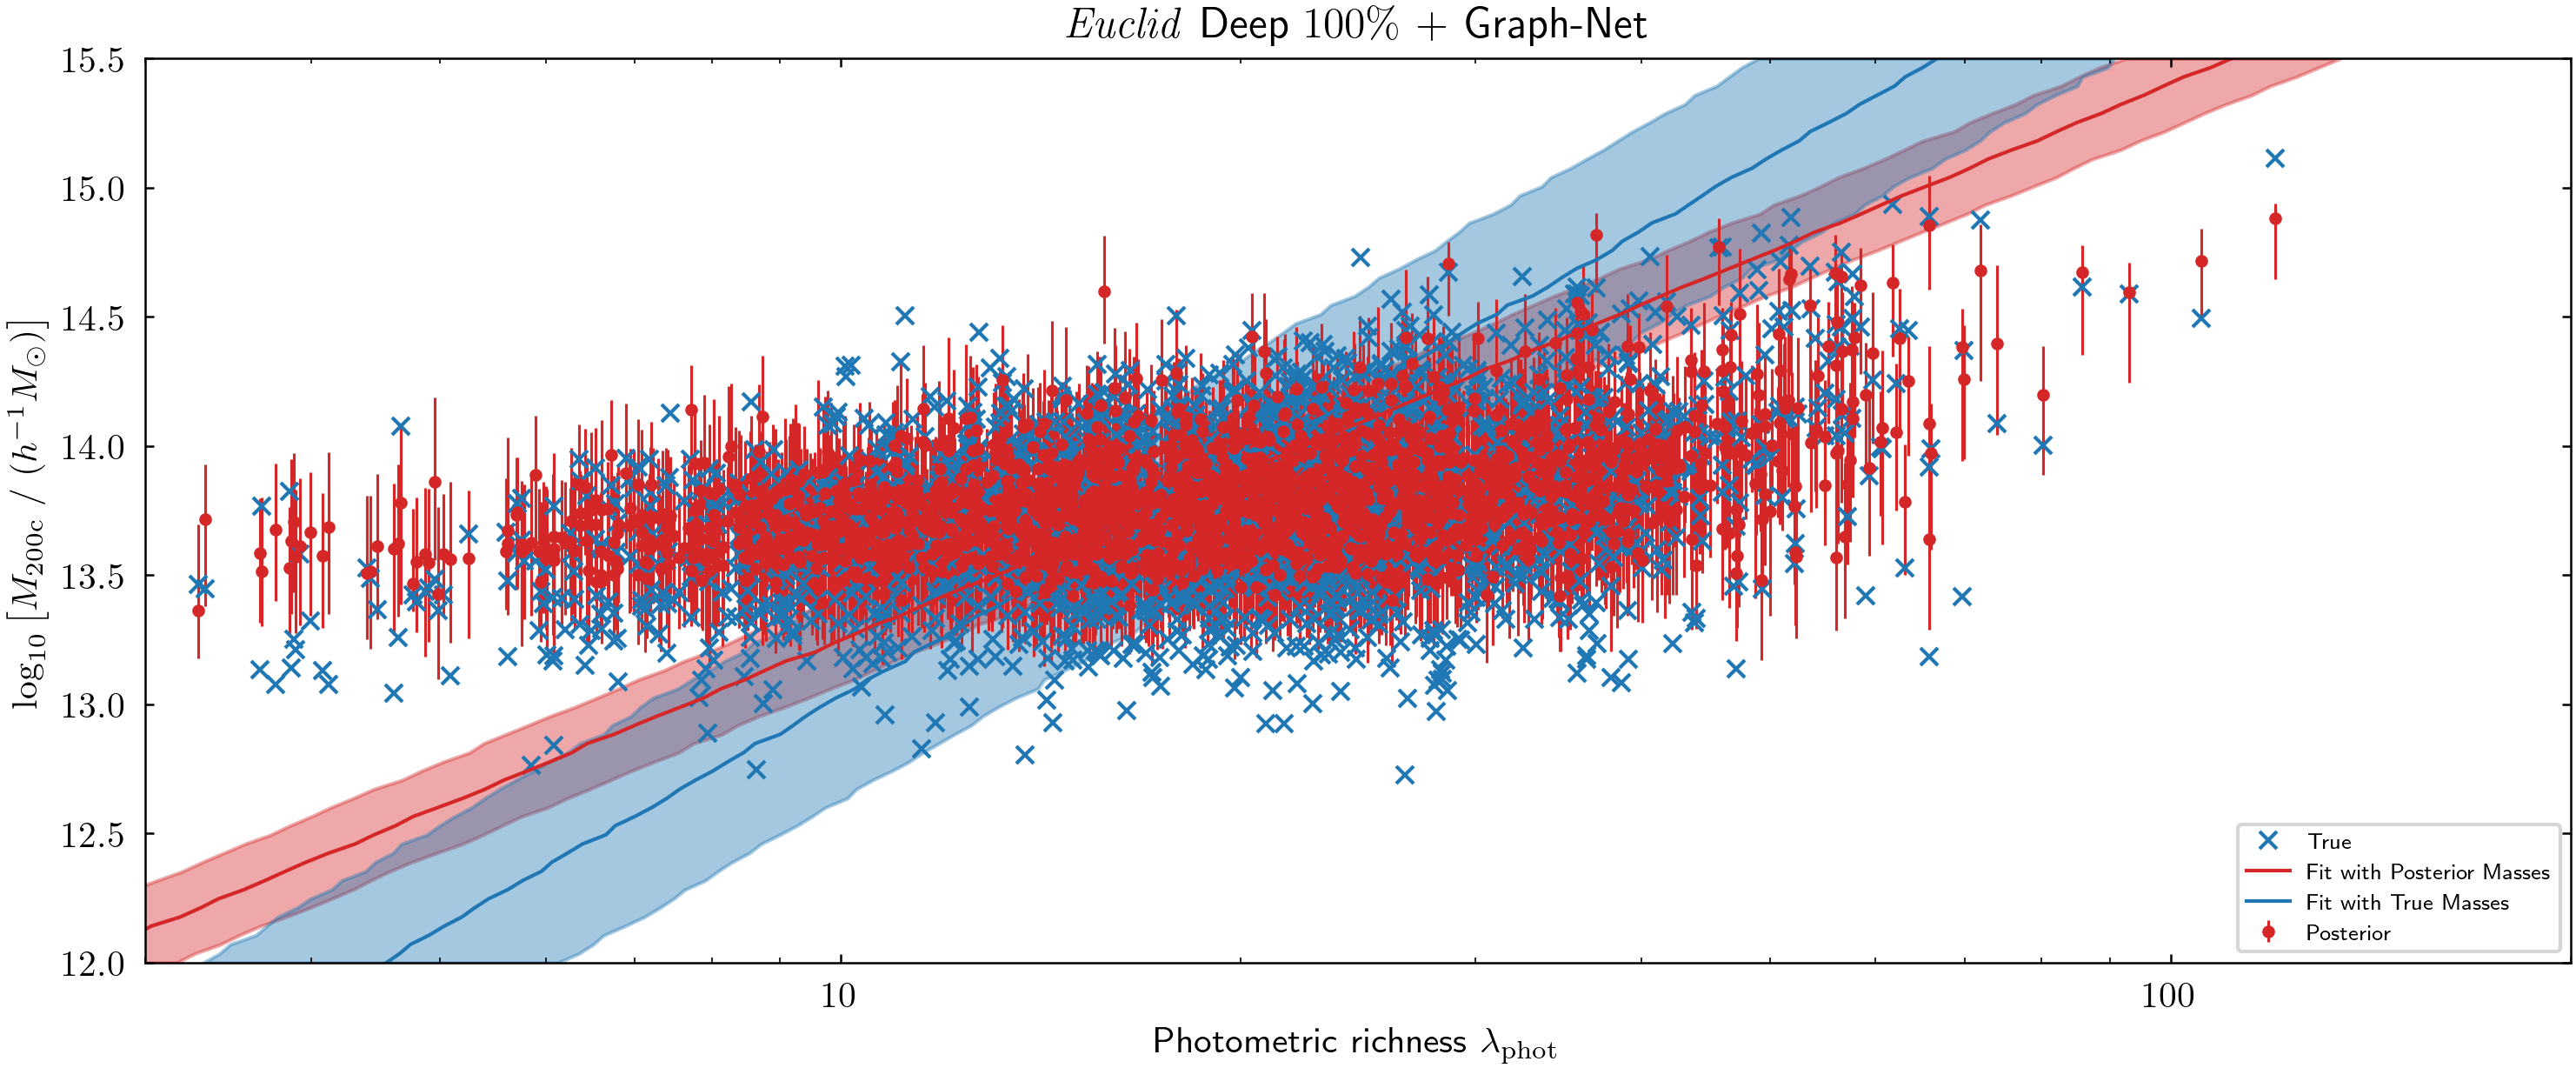

In [23]:
# Mass--richness fit: richness (x) vs M200c (y), as in v2
f, ax = plt.subplots(1, 1, figsize=(12, 4.5))
ax.semilogx()

# posterior mass samples (median + 16/84) vs observed richness
p_ = np.percentile(samps, [16, 50, 84], axis=1)
ax.errorbar(rs, p_[1], yerr=[p_[1]-p_[0], p_[2]-p_[1]],
            fmt='.', label='Posterior', alpha=1, elinewidth=0.75, color='C3')

# true masses vs observed richness
ax.plot(rs, ytrue, 'x', label='True', alpha=1, markersize=5, color='C0')

# forward fit: evaluate predicted richness on a mass grid (the y-axis), then
# draw the richness scatter as a horizontal band via fill_betweenx
xm = np.linspace(12., 15.5, 100)   # mass grid (y-axis)
for s, color, lab in [(samples, 'C3', 'Fit with Posterior Masses'),
                      (truesamples, 'C0', 'Fit with True Masses')]:
    lines = lamb_mean(xm[:, None], z0, m0_piv, z0, s['pi0'], s['Fm'], s['Gz'])
    lines = lines + s['sigl']*np.random.randn(*lines.shape)
    # richness at each mass
    pr = np.percentile(10**lines, [16, 50, 84], axis=1)
    ax.plot(pr[1], xm, label=lab, c=color)
    ax.fill_betweenx(xm, pr[0], pr[2], alpha=0.4, color=color)

ax.set_xlim(3, 200)
ax.set_ylim(12., 15.5)
ax.set_xlabel(r'Photometric richness $\lambda_{\rm phot}$')
ax.set_ylabel(r'$\log_{10}\left[M_{\rm 200c}\ /\ (h^{-1}M_{\odot})\right]$')
ax.set_title(f'$\it{{Euclid}}$ {datatitles[d]} + {modeltitles[m]}')
ax.get_xaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
ax.legend(loc='lower right', fontsize=6)

# f.savefig(f'figures/lambdam_fit_{d}.pdf', bbox_inches='tight')

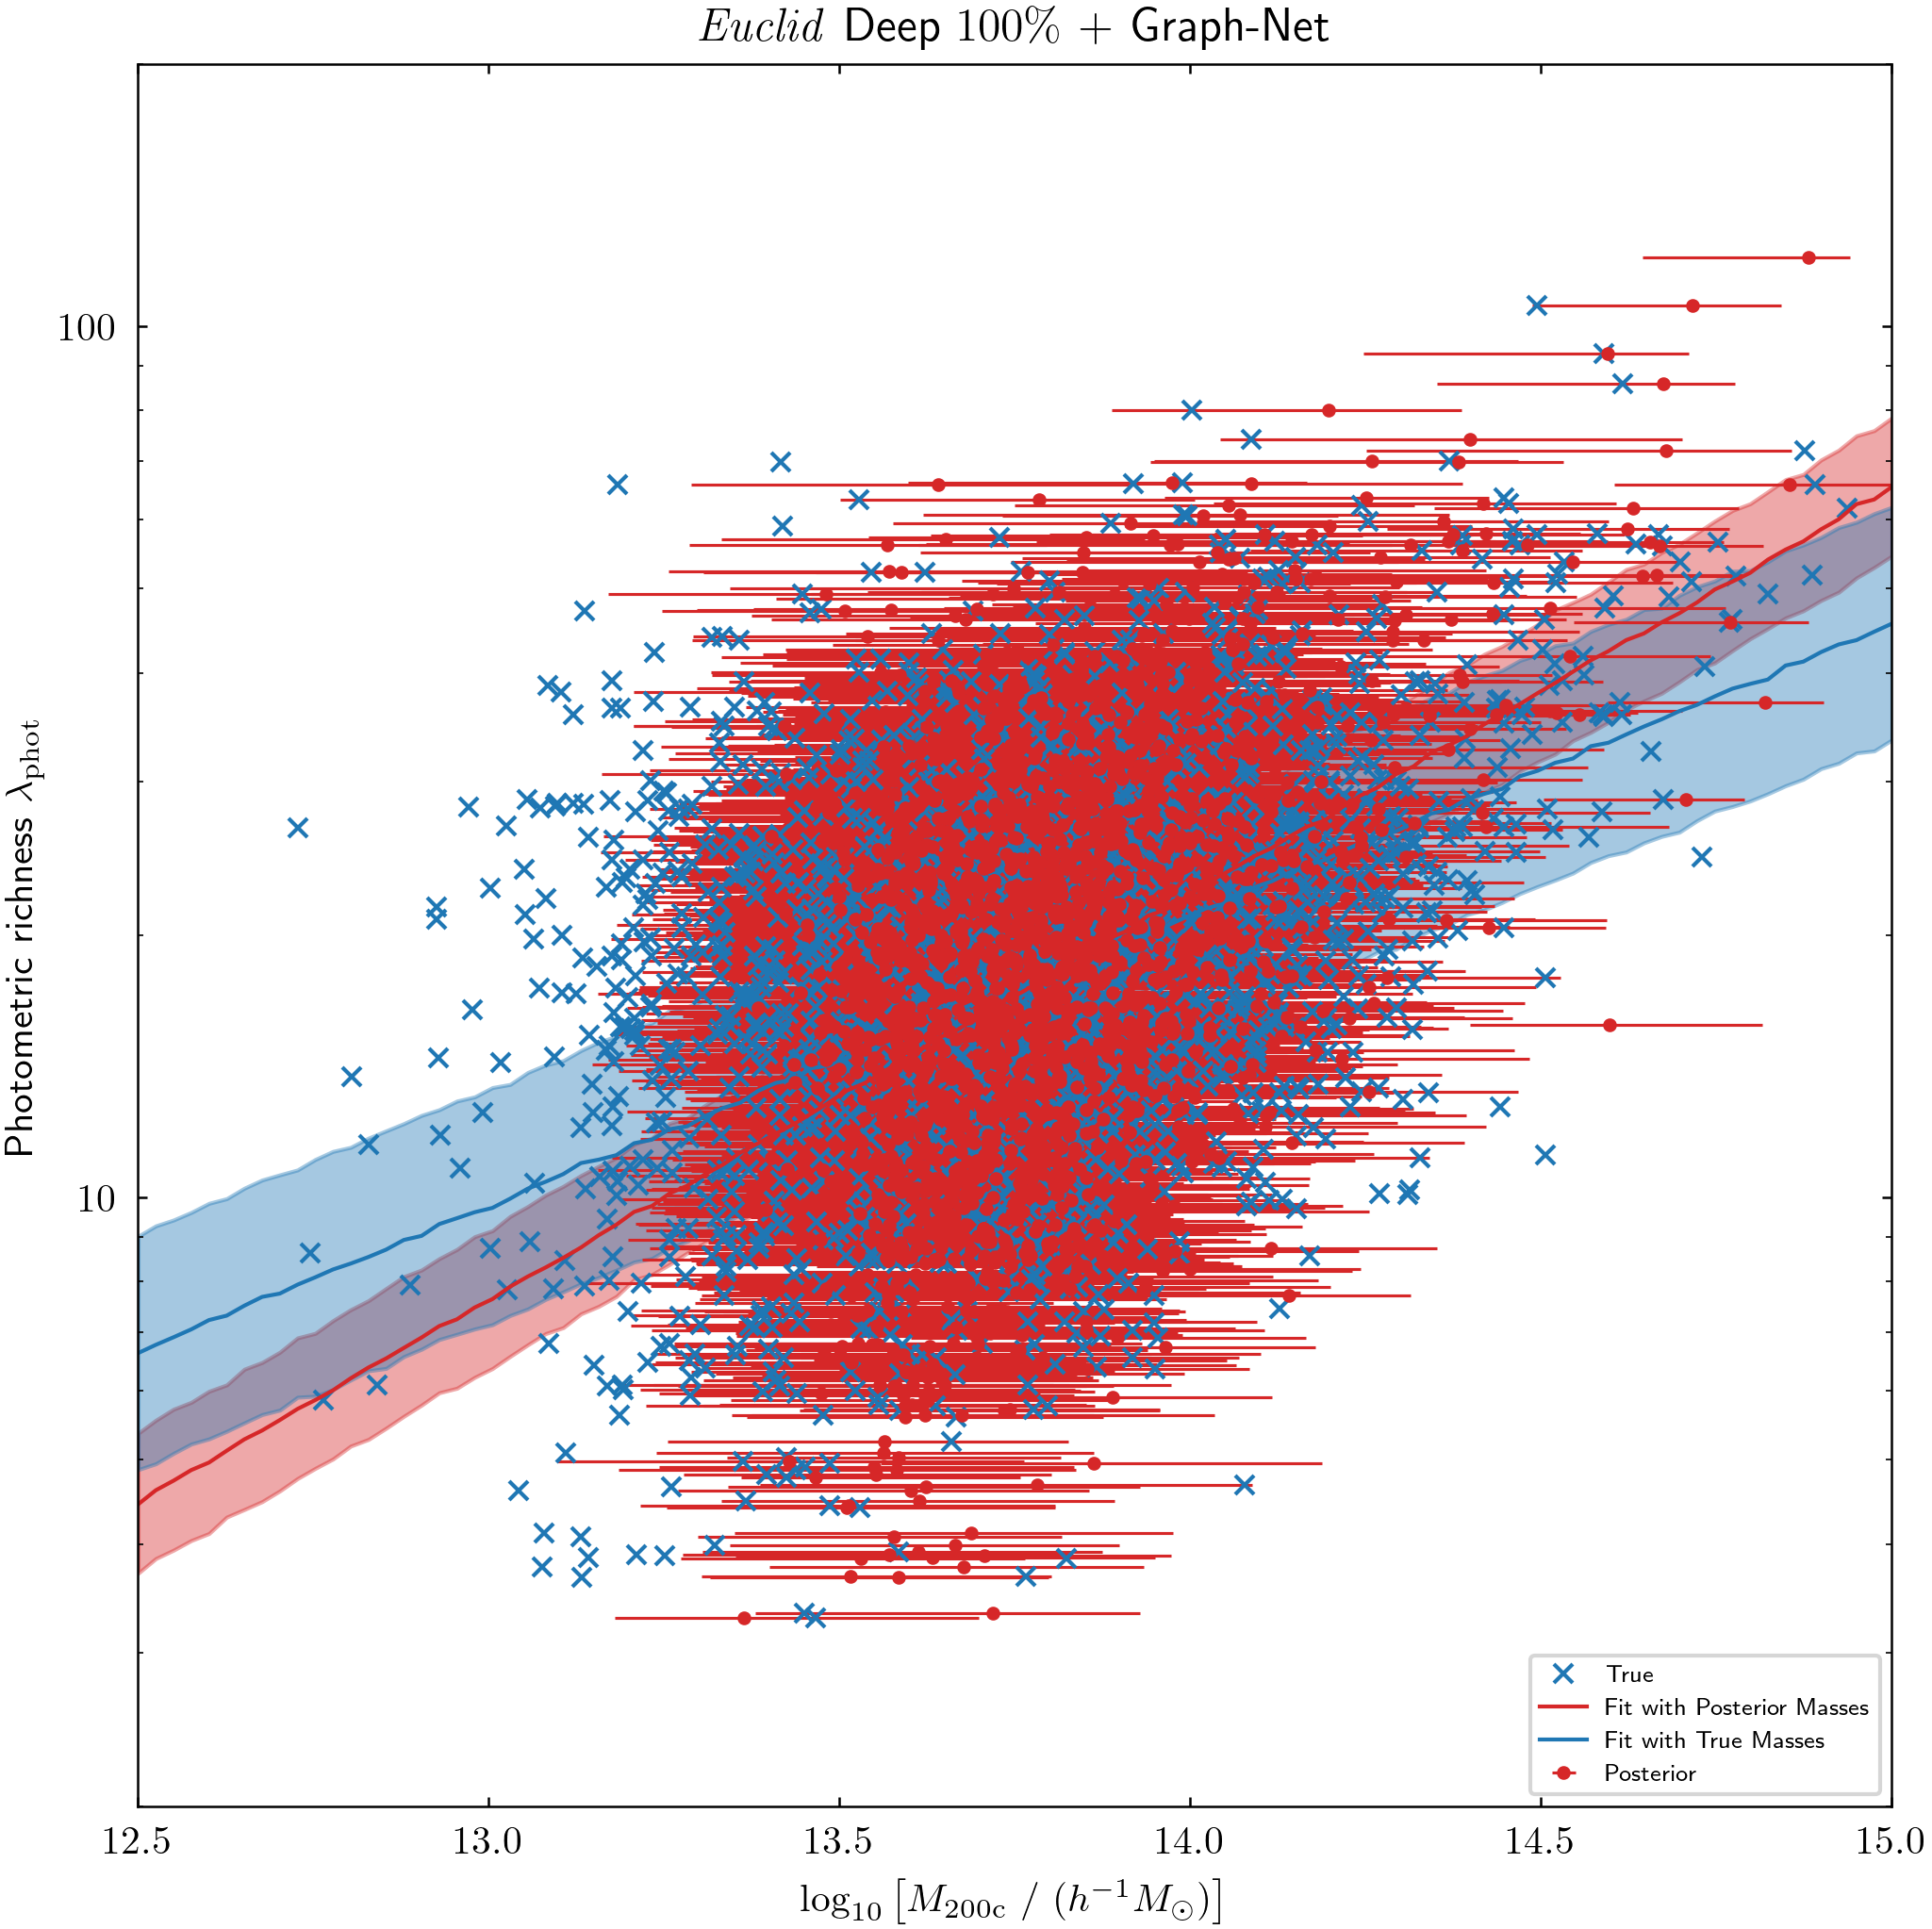

In [25]:
# Forward relation: predicted richness (y) as a function of mass (x)
f, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.semilogy()

# mass posteriors (x, median + 16/84) vs observed richness (y)
p_ = np.percentile(samps, [16, 50, 84], axis=1)
ax.errorbar(p_[1], rs, xerr=[p_[1]-p_[0], p_[2]-p_[1]],
            fmt='.', label='Posterior', alpha=1, elinewidth=0.75, color='C3')

# true masses (x) vs observed richness (y)
ax.plot(ytrue, rs, 'x', label='True', alpha=1, markersize=5, color='C0')

# fit grid in mass, evaluated at the redshift pivot
xm = np.linspace(12.5, 15.0, 100)

# fit with posterior masses, and with true masses (for reference)
for s, color, lab in [(samples, 'C3', 'Fit with Posterior Masses'),
                      (truesamples, 'C0', 'Fit with True Masses')]:
    lines = lamb_mean(xm[:, None], z0, m0_piv, z0, s['pi0'], s['Fm'], s['Gz'])
    lines = lines + s['sigl']*np.random.randn(*lines.shape)
    p_ = np.percentile(10**lines, [16, 50, 84], axis=1)
    ax.plot(xm, p_[1], label=lab, c=color)
    ax.fill_between(xm, p_[0], p_[2], alpha=0.4, color=color)

ax.set_xlim(12.5, 15.0)
ax.set_ylim(2, 200)
ax.set_xlabel(r'$\log_{10}\left[M_{\rm 200c}\ /\ (h^{-1}M_{\odot})\right]$')
ax.set_ylabel(r'Photometric richness $\lambda_{\rm phot}$')
ax.set_title(f'$\it{{Euclid}}$ {datatitles[d]} + {modeltitles[m]}')
ax.get_yaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
ax.legend(loc='lower right', fontsize=6)

# f.savefig(f'figures/lambdam_fit_{d}.pdf', bbox_inches='tight')

Mean ESS: 100.0 out of 100 samples
Minimum ESS: 99.7
Clusters with ESS < 10 (Danger Zone): 0


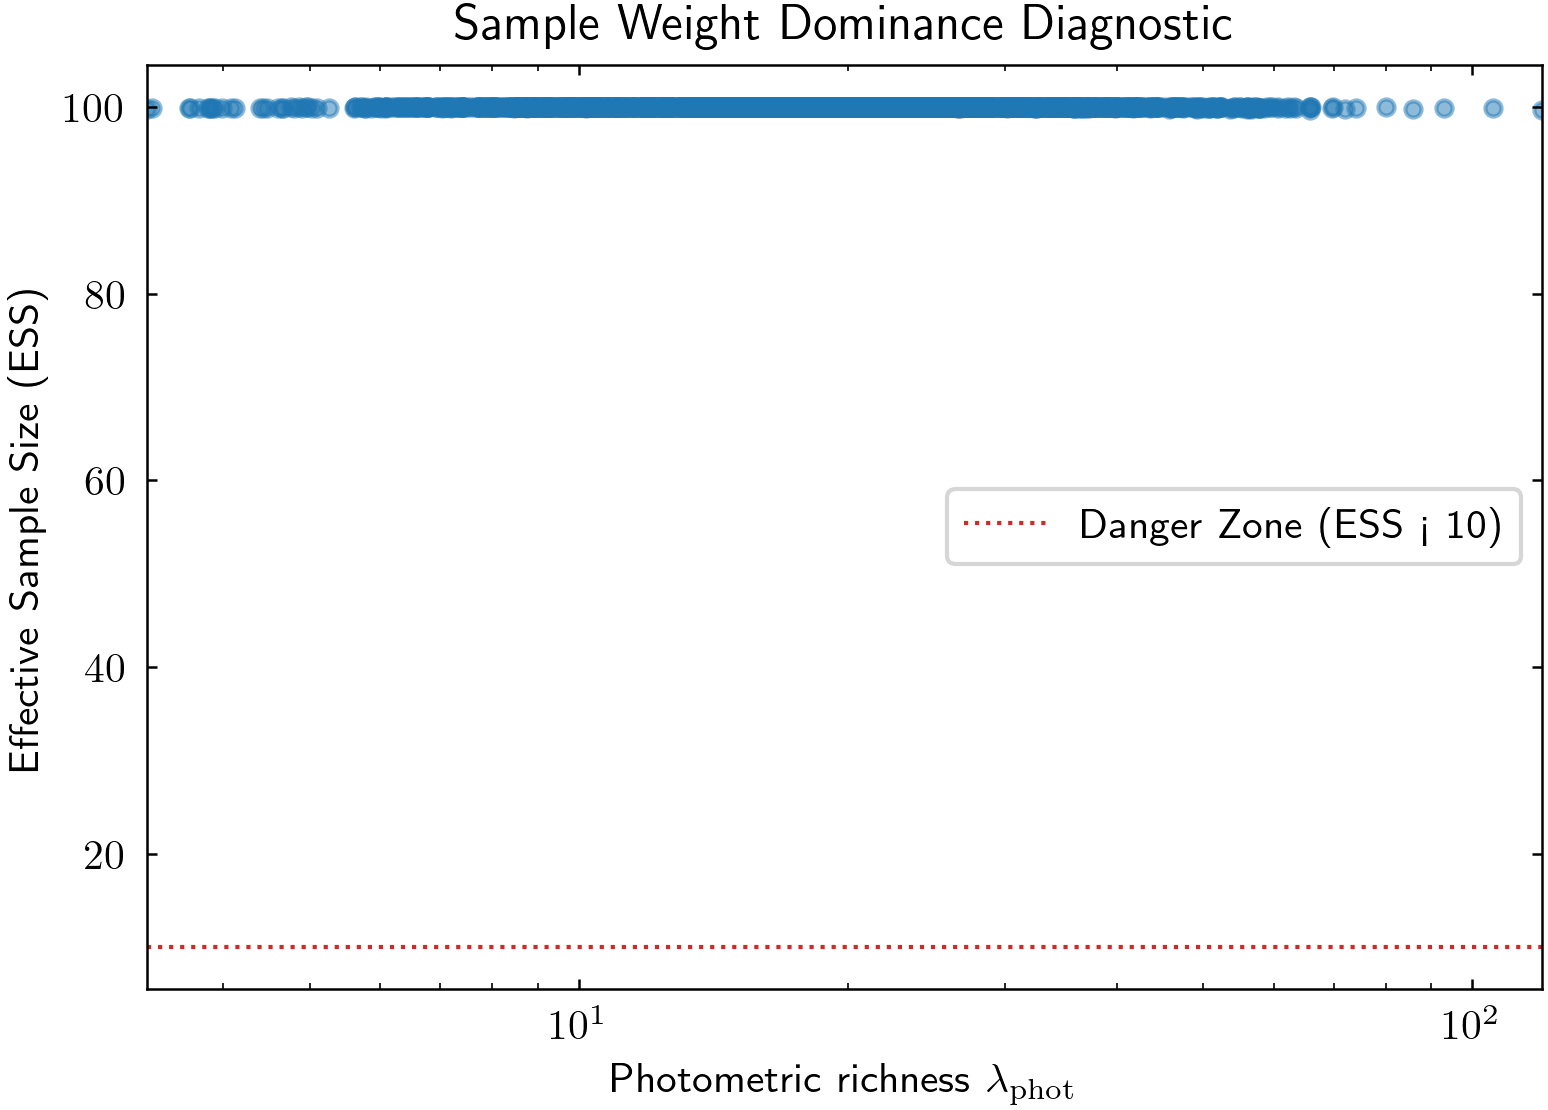

In [ ]:
# Calculate median parameters from the existing MCMC samples
med_pi0 = np.median(samples['pi0'])
med_Fm = np.median(samples['Fm'])
med_Gz = np.median(samples['Gz'])
med_sigl = np.median(samples['sigl'])

# Evaluate the operand (with the imposed-prior reweighting logw) for log-weights
log_weights = operand(samps, loglambs, zs, m0_piv, z0,
                      med_sigl, med_pi0, med_Fm, med_Gz, logw)

# Convert to normalized weights safely to prevent overflow
log_w_max = np.max(log_weights, axis=1, keepdims=True)
w = np.exp(log_weights - log_w_max)
w_norm = w / np.sum(w, axis=1, keepdims=True)

# Calculate Effective Sample Size (ESS) for each cluster
ess = 1.0 / np.sum(w_norm**2, axis=1)

print(f"Mean ESS: {np.mean(ess):.1f} out of {Nsamp} samples")
print(f"Minimum ESS: {np.min(ess):.1f}")
print(f"Clusters with ESS < 10 (Danger Zone): {np.sum(ess < 10)}")

# Plot ESS vs Richness to identify where the fit is breaking
f, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.scatter(rs, ess, alpha=0.5, s=15, color='C0')
ax.axhline(10, color='C3', linestyle=':', label='Danger Zone (ESS < 10)')
ax.set_xscale('log')
ax.set_xlabel(r'Photometric richness $\lambda_{\rm phot}$')
ax.set_ylabel('Effective Sample Size (ESS)')
ax.set_title('Sample Weight Dominance Diagnostic')
ax.legend()
plt.show()

[Text(0.5, 0, 'Photometric richness $\\lambda_{\\rm phot}$'),
 Text(0, 0.5, '$\\log_{10}\\left[M_{\\rm 200c}\\ /\\ (h^{-1}M_{\\odot})\\right]$')]

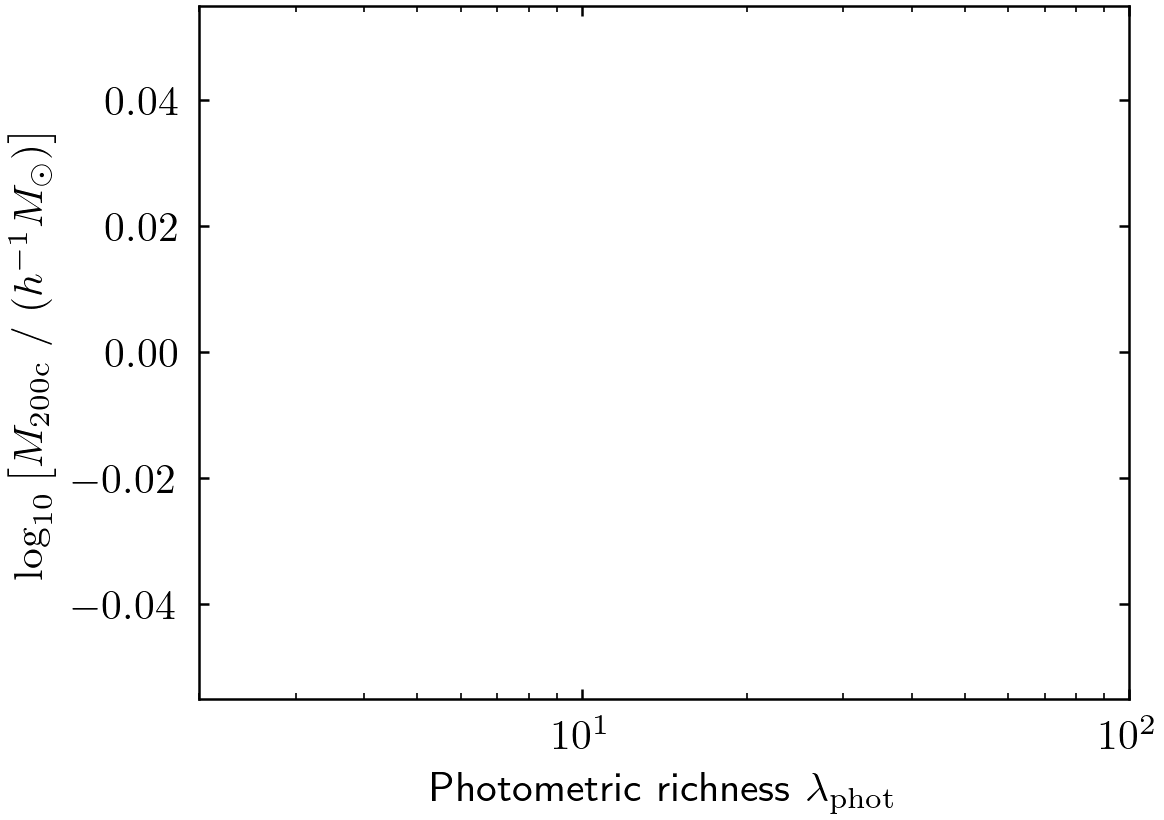

In [ ]:
mask = ess < 10


f, ax = plt.subplots()
for i in np.argwhere(mask):
    ax.plot(rs[i], ytrue[i], 'x')
    ax.errorbar(rs[i], samps[i].mean(), yerr=samps[i].std(), fmt='o')

ax.semilogx()
ax.set_xlim(2, 100)
ax.set(xlabel=r'Photometric richness $\lambda_{\rm phot}$',
       ylabel=r'$\log_{10}\left[M_{\rm 200c}\ /\ (h^{-1}M_{\odot})\right]$')